# Fase 1: Análisis Exploratorio de Datos (EDA) clínico y fisiológico

</div>

El objetivo de esta primera fase es explorar la distribución estadística de los datos y traducir las variables matemáticas a su significado fisiológico y cognitivo. Trabajar con el dataset **DARWIN** nos exige entender que cada fila es **paciente real** sometido a un test de estrés cognitivo-motor mediante escritura digital.

### Objetivos de este bloque:
1. **Configurar el entorno de visualización:** Estableciendo una paleta de colores semántica e intuitiva para facilitar la interpretación clínica (<span style="color:#2ca02c; font-weight:bold;">Verde = Control Sano</span> | <span style="color:#d62728; font-weight:bold;">Rojo = Paciente Alzheimer</span>).
2. **Carga y Control de Calidad (Sanity Check):** Verificación de las dimensiones de la cohorte, ausencia de valores nulos y unicidad de los pacientes para garantizar la integridad del estudio.
3. **Binarización de la variable objetivo:** Transformación de la etiqueta diagnóstica clínica a formato binario para facilitar el modelado algorítmico posterior.

In [1]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import math
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
import joblib

# Suprimimos warnings estéticos para mantener la limpieza del cuaderno
warnings.filterwarnings('ignore')

In [2]:
# 0. Configuración estética

sns.set_theme(style="white", context="talk")
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'white'
# Paleta semántica clínica para facilitar la interpretación visual de los datos
color_clases = {'H': '#27AE60', 'P': '#C0392B'}

In [3]:
# 1. Carga y sanity checks
df = pd.read_csv('../data/DARWIN.csv')

print(f"Dimensiones de la cohorte: {df.shape[0]} participantes y {df.shape[1]} variables.")
print(f"Valores nulos totales en el dataset: {df.isnull().sum().sum()}")

# Control de integridad clínico - Verificamos que no hay pacientes duplicados
ids_duplicados = df['ID'].duplicated().sum()
print(f"Pacientes con ID duplicado (medidas repetidas): {ids_duplicados}")

Dimensiones de la cohorte: 174 participantes y 452 variables.
Valores nulos totales en el dataset: 0
Pacientes con ID duplicado (medidas repetidas): 0


In [4]:
# Transformación de la variable objetivo

# Transformamos la clase a binario para facilitar el análisis y modelado posterior
# P (Patient) -> 1, H (Healthy) -> 0
df['class_num'] = df['class'].map({'P': 1, 'H': 0})

### 2. Balance de la Cohorte (Distribución Diagnóstica)

En el desarrollo de algoritmos de Machine Learning clínico, el desbalance de clases es uno de los principales factores de riesgo. Un dataset desbalanceado genera modelos sesgados que priorizan la precisión global ignorando la sensibilidad hacia la clase minoritaria.

Demostrar un balance adecuado en nuestra cohorte original es crucial, ya que nos permite:
* Utilizar métricas de rendimiento estándar y robustas de forma directa.
* Evitar técnicas de sobremuestreo artificial (como SMOTE), garantizando que el modelo aprenda **exclusivamente de variabilidad fisiológica real** y no de datos sintéticos.

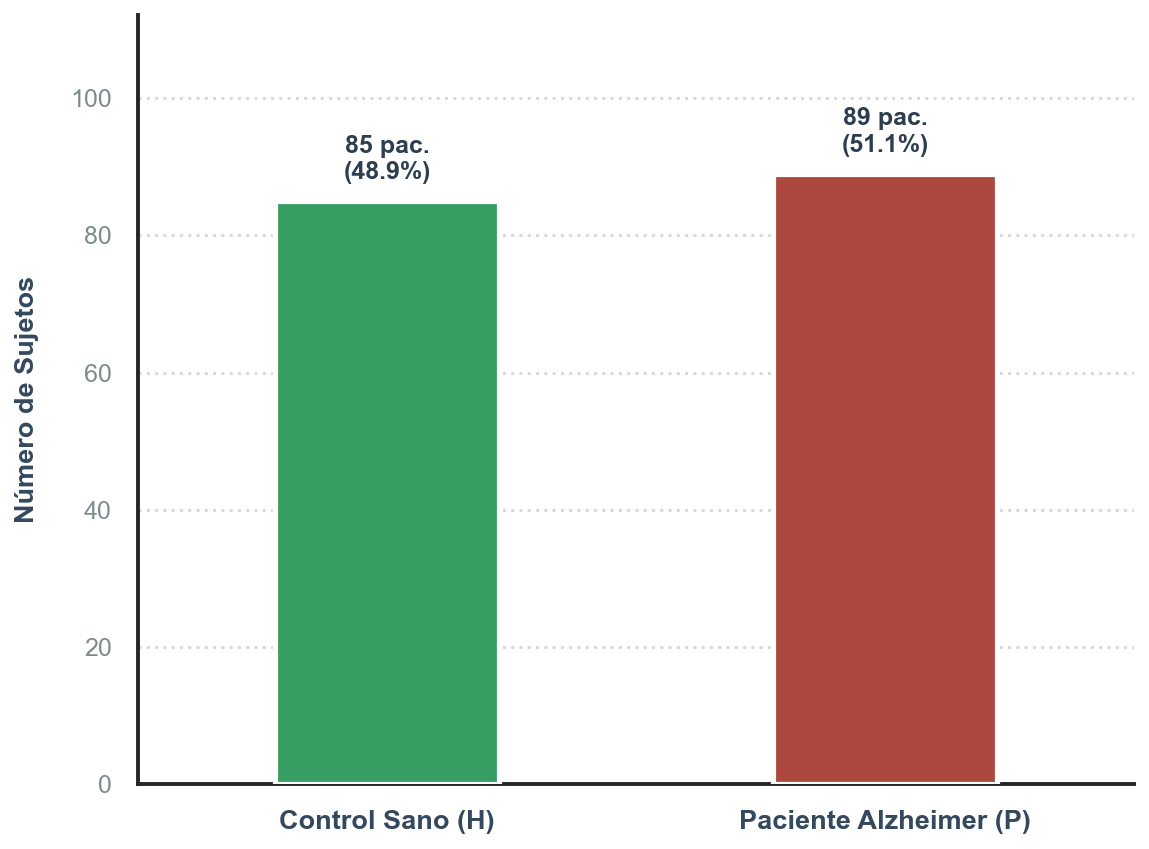

In [5]:
fig, ax = plt.subplots(figsize=(8, 6), dpi=150)

sns.countplot(data=df, x='class', palette=color_clases, order=['H', 'P'], 
              ax=ax, edgecolor='white', linewidth=2.5, width=0.45, zorder=3)
ax.set_xticklabels(['Control Sano (H)', 'Paciente Alzheimer (P)'], 
                   fontweight='bold', color='#34495E', fontsize=13)
ax.set_xlabel('')

ax.set_ylabel('Número de Sujetos', fontsize=13, fontweight='bold', labelpad=15, color='#34495E')
ax.tick_params(axis='y', labelsize=12, colors='#7F8C8D')

ax.grid(axis='y', linestyle=':', alpha=0.6, color='#BDC3C7', zorder=0)
sns.despine()

total = len(df)
for p in ax.patches:
    altura = p.get_height()
    porcentaje = f'{100 * altura / total:.1f}%'
    texto = f'{int(altura)} pac.\n({porcentaje})'
    
    ax.annotate(texto, 
                (p.get_x() + p.get_width() / 2., altura), 
                ha='center', va='bottom', 
                fontsize=12, fontweight='bold', color='#2C3E50', 
                xytext=(0, 8), textcoords='offset points',
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8))

ax.set_ylim(0, ax.get_ylim()[1] * 1.20)

plt.tight_layout()
plt.show()

In [6]:
# Extraemos los valores reales para imprimirlos como conclusión
conteo = df['class'].value_counts()
print(f"Cohorte total: {total} sujetos.")
print(f"Controles Sanos (H): {conteo.get('H', 0)} | Pacientes Alzheimer (P): {conteo.get('P', 0)}")
print("El dataset presenta un balance natural de aproximadamente 50/50.")

Cohorte total: 174 sujetos.
Controles Sanos (H): 85 | Pacientes Alzheimer (P): 89
El dataset presenta un balance natural de aproximadamente 50/50.


### Análisis fisiológico basal (Cognición vs. Control Motor)

El diagnóstico del Alzheimer a través de la escritura no se basa en *"qué"* escribe el paciente, sino en *"cómo"* lo escribe. Analizaremos la Tarea 1 (basal) desglosando el acto de escribir en tres dimensiones fisiológicas:

1. **Carga Cognitiva (`air_time`):** Tiempo que el bolígrafo está en el aire. Mide la duda, la planificación espacial y la bradicinesia cognitiva.
2. **Pérdida de Control Motor (`mean_jerk`):** Derivada de la aceleración. Valores altos indican pérdida de fluidez, micro-temblores y apraxia.
3. **Fuerza Muscular (`pressure_mean`):** Presión ejercida sobre la tableta, indicando tono muscular y seguridad en el trazo.

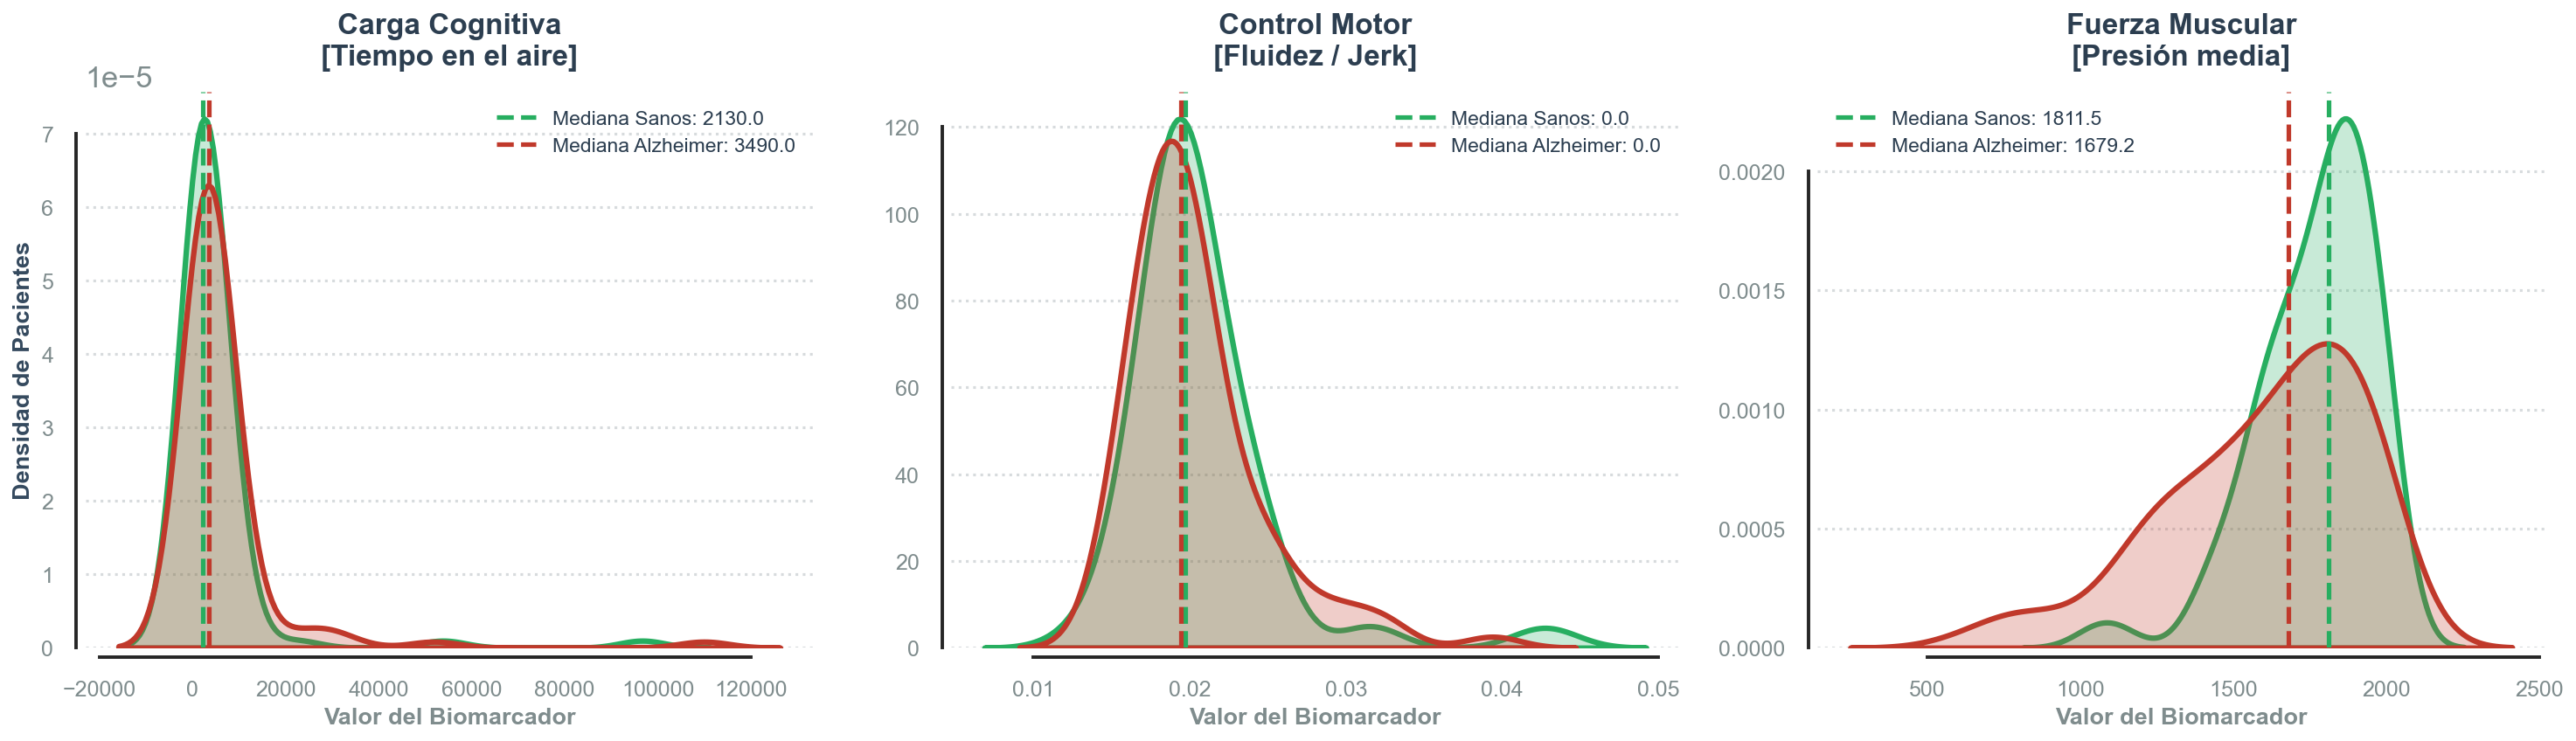

Mediana en controles sanos (H) : 2130 ms
Mediana en pacientes (P)       : 3490 ms
Carga cognitiva: Los pacientes con Alzheimer pausan un 63.8% MÁS.


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), dpi=150)

variables_clinicas = [
    ('air_time1', 'Carga Cognitiva\n[Tiempo en el aire]'),
    ('mean_jerk_on_paper1', 'Control Motor\n[Fluidez / Jerk]'),
    ('pressure_mean1', 'Fuerza Muscular\n[Presión media]')
]

for i, (var, titulo) in enumerate(variables_clinicas):
    axes[i].set_facecolor('#FFFFFF')
    
    # Curva KDE (Distribución)
    sns.kdeplot(data=df, x=var, hue='class', palette=color_clases, 
                fill=True, common_norm=False, alpha=0.25, ax=axes[i], 
                linewidth=3, zorder=3)
    
    # Cálculo de medianas
    mediana_H = df[df['class'] == 'H'][var].median()
    mediana_P = df[df['class'] == 'P'][var].median()
    
    # Líneas de mediana verticales
    axes[i].axvline(mediana_H, color=color_clases['H'], linestyle='--', linewidth=2.5, 
                    label=f'Mediana Sanos: {mediana_H:.1f}', zorder=4)
    axes[i].axvline(mediana_P, color=color_clases['P'], linestyle='--', linewidth=2.5, 
                    label=f'Mediana Alzheimer: {mediana_P:.1f}', zorder=4)
    
    # Estética del Subgráfico
    axes[i].set_title(titulo, fontsize=16, fontweight='bold', pad=15, color='#2C3E50')
    axes[i].set_xlabel('Valor del Biomarcador', fontsize=13, fontweight='bold', color='#7F8C8D')
    
    # Solo mostramos el eje Y en el primer gráfico para evitar redundancia
    if i == 0:
        axes[i].set_ylabel('Densidad de Pacientes', fontsize=13, fontweight='bold', color='#34495E')
    else:
        axes[i].set_ylabel('') 
        
    axes[i].tick_params(axis='both', labelsize=12, colors='#7F8C8D')
    
    # Grid horizontal sutil
    axes[i].grid(axis='y', linestyle=':', alpha=0.6, color='#BDC3C7', zorder=0)

    # Limpiamos la leyenda automática de Seaborn (que suele ser fea)
    if axes[i].get_legend() is not None:
        axes[i].get_legend().remove()
        
    # Creamos una leyenda limpia sin marco
    axes[i].legend(loc='best', frameon=False, fontsize=11, labelcolor='#2C3E50')


sns.despine(trim=True, offset=5)
plt.tight_layout()
plt.show()

med_air_H = df[df['class']=='H']['air_time1'].median()
med_air_P = df[df['class']=='P']['air_time1'].median()
incremento_air = ((med_air_P - med_air_H) / med_air_H) * 100


print(f"Mediana en controles sanos (H) : {med_air_H:.0f} ms")
print(f"Mediana en pacientes (P)       : {med_air_P:.0f} ms")
print(f"Carga cognitiva: Los pacientes con Alzheimer pausan un {incremento_air:.1f}% MÁS.")

### Validación estadística de biomarcadores (prueba no paramétrica)

La apreciación visual de las gráficas de densidad debe respaldarse empíricamente. Dado que las métricas biomecánicas y cognitivas presentan asimetrías y *outliers* patológicos naturales que violan el supuesto de normalidad, descartamos el T-Student clásico. 

Aplicamos la **Prueba U de Mann-Whitney**, un método no paramétrico altamente robusto:
* **Nivel de significancia ($\alpha$):** `0.05`
* **Hipótesis nula ($H_0$):** La distribución del biomarcador es idéntica en Controles Sanos y en Pacientes con Alzheimer.
* **Criterio:** Si el P-Valor < 0.05, rechazamos $H_0$ y el biomarcador se considera clínicamente relevante.

In [8]:
conclusiones_validas = 0

for var, titulo in variables_clinicas:
    # Filtramos usando la columna class ('H' y 'P')
    sanos = df[df['class'] == 'H'][var]
    pacientes = df[df['class'] == 'P'][var]
    
    # Aplicamos el test estadístico a dos colas
    stat, p_value = stats.mannwhitneyu(sanos, pacientes, alternative='two-sided')
    
    # Formateamos el resultado para el reporte
    if p_value < 0.05:
        sig = "Significativo"
        conclusiones_validas += 1
    else:
        sig = "No significativo"
        
    # Usamos notación científica para p-valores muy pequeños
    print(f"{titulo}:")
    print(f"p-Valor = {p_value:.5e} ({sig})\n")

Carga Cognitiva
[Tiempo en el aire]:
p-Valor = 2.54248e-03 (Significativo)

Control Motor
[Fluidez / Jerk]:
p-Valor = 5.07745e-01 (No significativo)

Fuerza Muscular
[Presión media]:
p-Valor = 5.60048e-04 (Significativo)



### 5. Análisis de colinealidad y redundancia intra-tarea

> **El peligro de la redundancia:** Cuando múltiples variables miden el mismo fenómeno fisiológico, introducen ruido, aumentan el *overfitting* y destruyen la interpretabilidad (XAI) al diluir la importancia predictiva entre características idénticas.

En este apartado buscamos demostrar empíricamente la alta colinealidad (correlación de Pearson) entre variables de una misma tarea. Este hallazgo es la **justificación metodológica** para aplicar técnicas de Selección de Variables (*Feature Selection*) en la Fase 2.

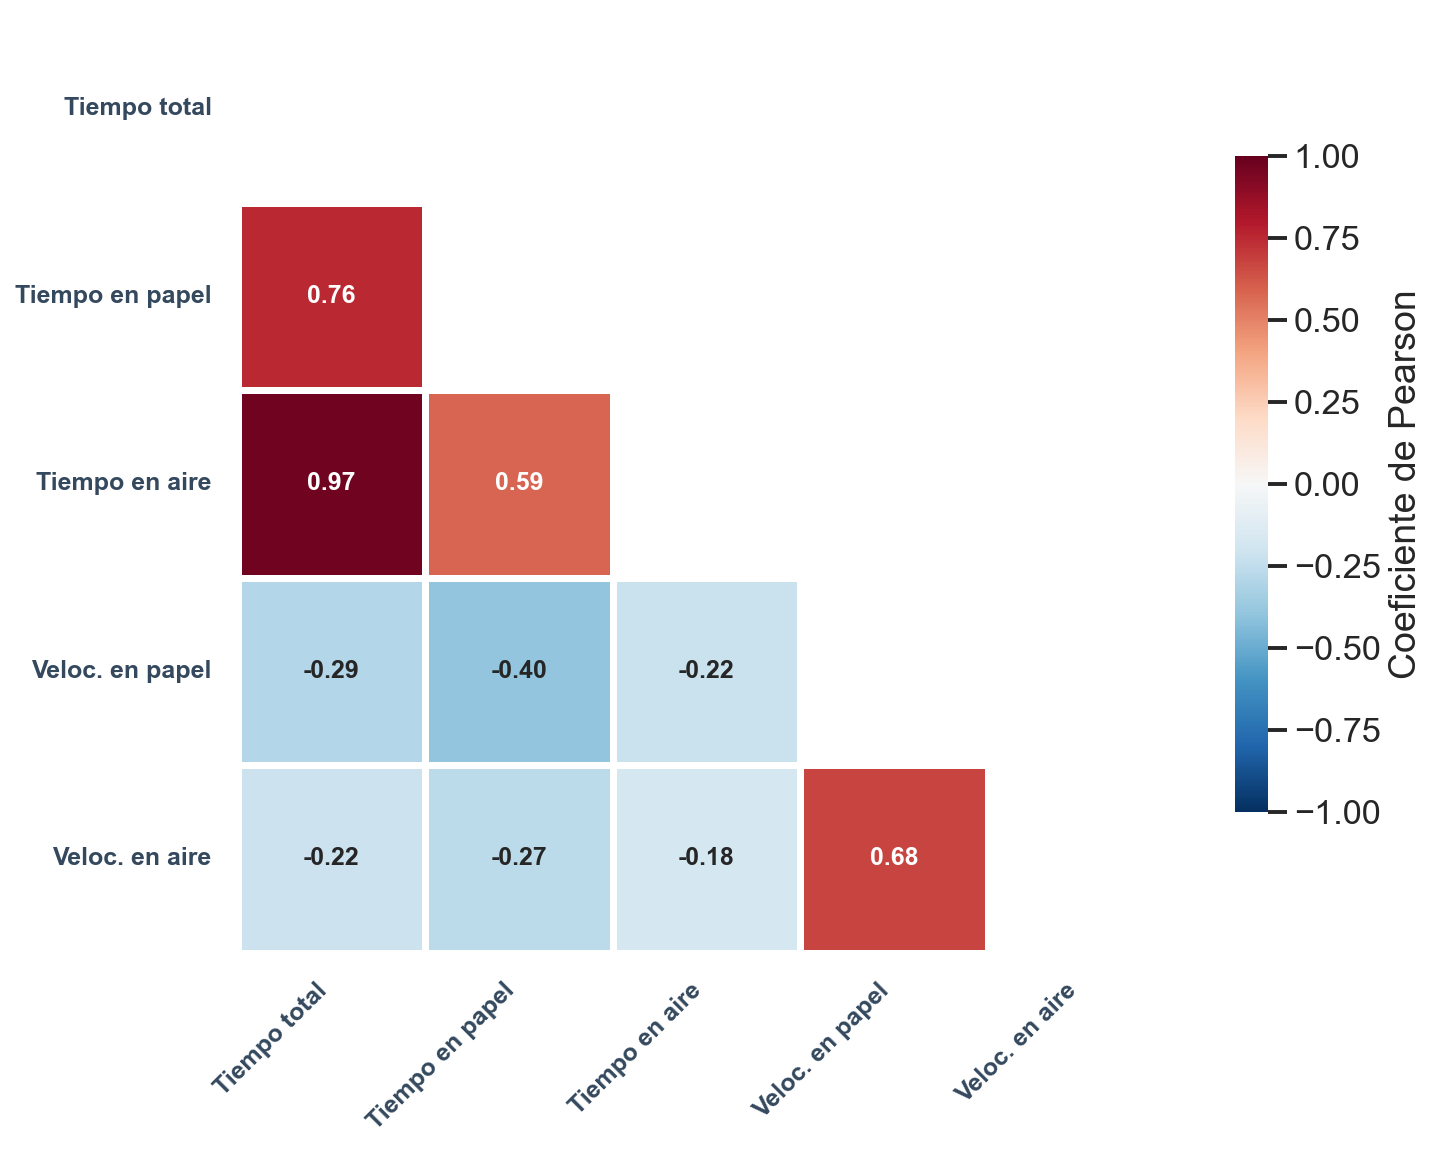

In [9]:
vars_tiempo = ['total_time1', 'paper_time1', 'air_time1', 
               'mean_speed_on_paper1', 'mean_speed_in_air1']

nombres_clinicos = {
    'total_time1': 'Tiempo total',
    'paper_time1': 'Tiempo en papel',
    'air_time1': 'Tiempo en aire',
    'mean_speed_on_paper1': 'Veloc. en papel',
    'mean_speed_in_air1': 'Veloc. en aire'
}

corr_matrix = df[vars_tiempo].rename(columns=nombres_clinicos).corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8), dpi=150)

sns.heatmap(corr_matrix, 
            mask=mask, 
            annot=True, 
            cmap='RdBu_r',
            vmin=-1, vmax=1, center=0, 
            fmt=".2f", 
            square=True, 
            linewidths=2.5,
            linecolor='white',
            cbar_kws={"shrink": .7, "label": "Coeficiente de Pearson"}, 
            annot_kws={"size": 12, "weight": "bold"},
            ax=ax)


plt.xticks(rotation=45, ha='right', fontsize=12, fontweight='bold', color='#34495E')
plt.yticks(rotation=0, fontsize=12, fontweight='bold', color='#34495E')
plt.tight_layout()
plt.show()

### 6. Macro-EDA: Perfil Fisiológico Global (Agregación Longitudinal)

Hasta ahora hemos analizado el rendimiento basal (Tarea 1) y la evolución del agotamiento (Fatiga). Sin embargo, el protocolo DARWIN consta de 25 tareas heterogéneas. Analizar cada tarea de forma aislada introduce un alto nivel de ruido estadístico (varianza intra-sujeto) e infla artificialmente la dimensionalidad del problema.

Para capturar la "huella clínica integral" de la enfermedad, aplicaremos una técnica de **reducción de dimensionalidad basada en conocimiento de dominio**. Consiste en colapsar las 452 variables en sus **18 dimensiones fisiológicas base**, calculando su comportamiento global a lo largo de toda la prueba:
* **Agregación por Suma:** Para variables acumulativas (ej. Tiempo en el Aire, Levantamientos de bolígrafo), obteniendo la *Carga cognitiva total*.
* **Agregación por Media:** Para variables cinemáticas y dinámicas (ej. Aceleración, Presión, *Jerk*), obteniendo el *Tono motor promedio*.

El objetivo de este panel global es identificar de un solo vistazo qué dimensiones fisiológicas presentan una separación natural entre sanos y enfermos, revelando los biomarcadores estrella que guiarán a nuestros algoritmos predictivos.

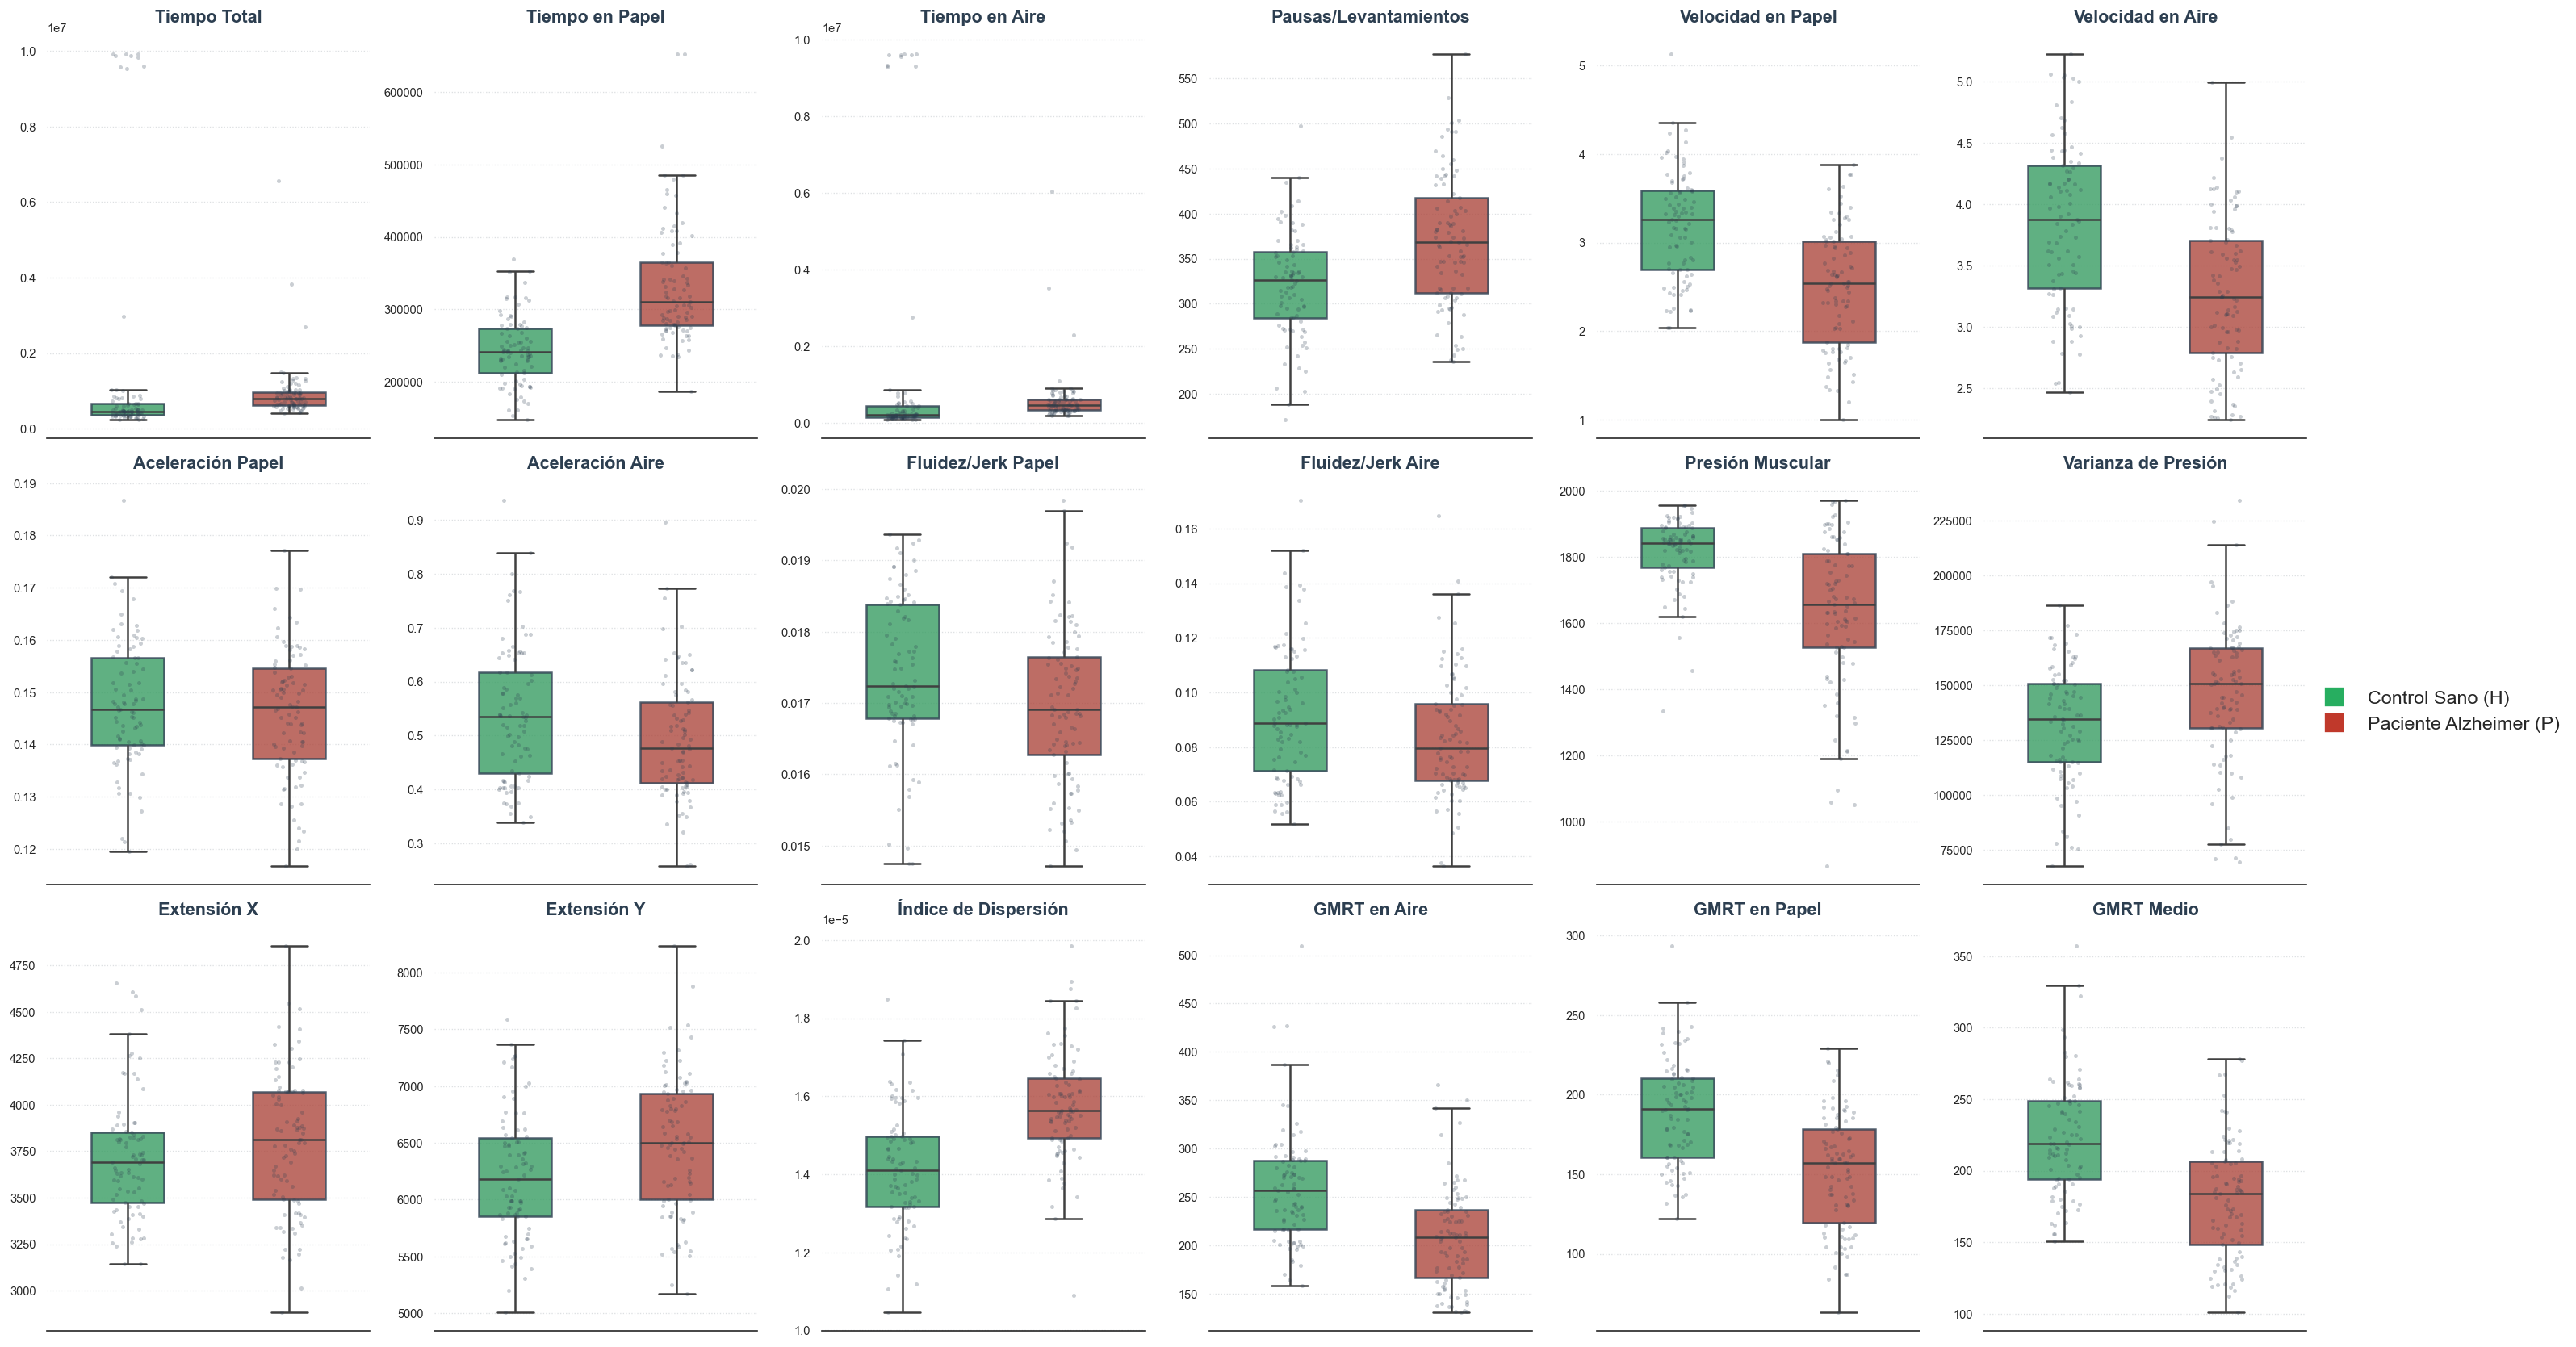

In [10]:
# Diccionario con las 18 variables base y su método lógico de agregación clínica

variables_base = {
'total_time': ('sum', 'Tiempo Total (Suma ms)'),
'paper_time': ('sum', 'Tiempo en Papel (Suma ms)'),
'air_time': ('sum', 'Tiempo en Aire (Suma ms)'),
'num_of_pendown': ('sum', 'Pausas/Levantamientos (Suma)'),
'mean_speed_on_paper': ('mean', 'Velocidad en Papel (Media)'),
'mean_speed_in_air': ('mean', 'Velocidad en Aire (Media)'),
'mean_acc_on_paper': ('mean', 'Aceleración Papel (Media)'),
'mean_acc_in_air': ('mean', 'Aceleración Aire (Media)'),
'mean_jerk_on_paper': ('mean', 'Fluidez/Jerk Papel (Media)'),
'mean_jerk_in_air': ('mean', 'Fluidez/Jerk Aire (Media)'),
'pressure_mean': ('mean', 'Presión Muscular (Media)'),
'pressure_var': ('mean', 'Varianza de Presión (Media)'),
'max_x_extension': ('mean', 'Extensión X (Media)'),
'max_y_extension': ('mean', 'Extensión Y (Media)'),
'disp_index': ('mean', 'Índice de Dispersión (Media)'),
'gmrt_in_air': ('mean', 'GMRT en Aire (Media)'),
'gmrt_on_paper': ('mean', 'GMRT en Papel (Media)'),
'mean_gmrt': ('mean', 'GMRT Medio (Media)')
}

df_macro = pd.DataFrame()
df_macro['class'] = df['class']
for var_base, (metodo, titulo) in variables_base.items():
    columnas_tarea = [col for col in df.columns if col.startswith(var_base) and col not in ['class', 'class_num', 'class', 'delta_fatiga_air']]
    if metodo == 'sum':
        df_macro[f'global_{var_base}'] = df[columnas_tarea].sum(axis=1)
    else:
        df_macro[f'global_{var_base}'] = df[columnas_tarea].mean(axis=1)

sns.set_theme(style="white", context="paper")
fig, axes = plt.subplots(3, 6, figsize=(24, 14), dpi=120)
fig.patch.set_facecolor('#FFFFFF')

axes = axes.flatten()

for i, (var_base, (metodo, titulo)) in enumerate(variables_base.items()):
    col_name = f'global_{var_base}'
    ax = axes[i]
    ax.set_facecolor('#FFFFFF')
    sns.boxplot(data=df_macro, x='class', y=col_name, palette=color_clases, order=['H', 'P'], 
                ax=ax, width=0.45, fliersize=0, linewidth=1.5, zorder=2,
                boxprops=dict(edgecolor='#2C3E50', alpha=0.8))
    sns.stripplot(data=df_macro, x='class', y=col_name, color='#2C3E50', alpha=0.25, 
                  jitter=True, order=['H', 'P'], ax=ax, size=3, zorder=3)
    ax.set_title(titulo.split(' (')[0], fontsize=13, fontweight='bold', color='#2C3E50', pad=10)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticklabels([])
    ax.grid(axis='y', linestyle=':', alpha=0.5, color='#BDC3C7', zorder=0)
    sns.despine(ax=ax, left=True)
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='s', color='w', label='Control Sano (H)', 
           markerfacecolor=color_clases['H'], markersize=15),
    Line2D([0], [0], marker='s', color='w', label='Paciente Alzheimer (P)', 
           markerfacecolor=color_clases['P'], markersize=15)
]

fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.11, 0.5), 
           frameon=False, fontsize=14, ncol=1)


plt.tight_layout()
plt.show()

### 7. EDA Avanzado: Fatiga Cognitiva Intrasujeto y Espacio Latente (PCA)

En esta fase final del EDA, queremos obtener respuesta a dos cuestiones fundamentales para la viabilidad clínica del sistema y el diseño de la arquitectura de Machine Learning:

**A) Evolución Longitudinal (Fatiga Intrasujeto):** El protocolo DARWIN consta de 25 tareas. Someter a un paciente de edad avanzada a un test prolongado puede inducir fatiga, alterando los resultados. Para cuantificar esto, diseñamos un biomarcador derivado denominado `delta_fatiga_air` (Diferencia de tiempo en el aire entre la Tarea 25 y la Tarea 1). Un incremento significativo de las pausas en la cohorte patológica justificaría algorítmicamente la necesidad de acortar la prueba mediante técnicas de *Feature Selection*.

**B) Proyección Multivariante (Análisis de Componentes Principales - PCA):**
Con 450 variables biomecánicas, nos enfrentamos a la "maldición de la dimensionalidad". Aplicamos PCA para comprimir el dataset en un espacio bidimensional (reducción lineal no supervisada). El objetivo no es clasificar, sino visualizar si existe una "firma matemática" subyacente que separe de forma natural los cerebros sanos de los neurodegenerativos antes de aplicar algoritmos predictivos complejos.

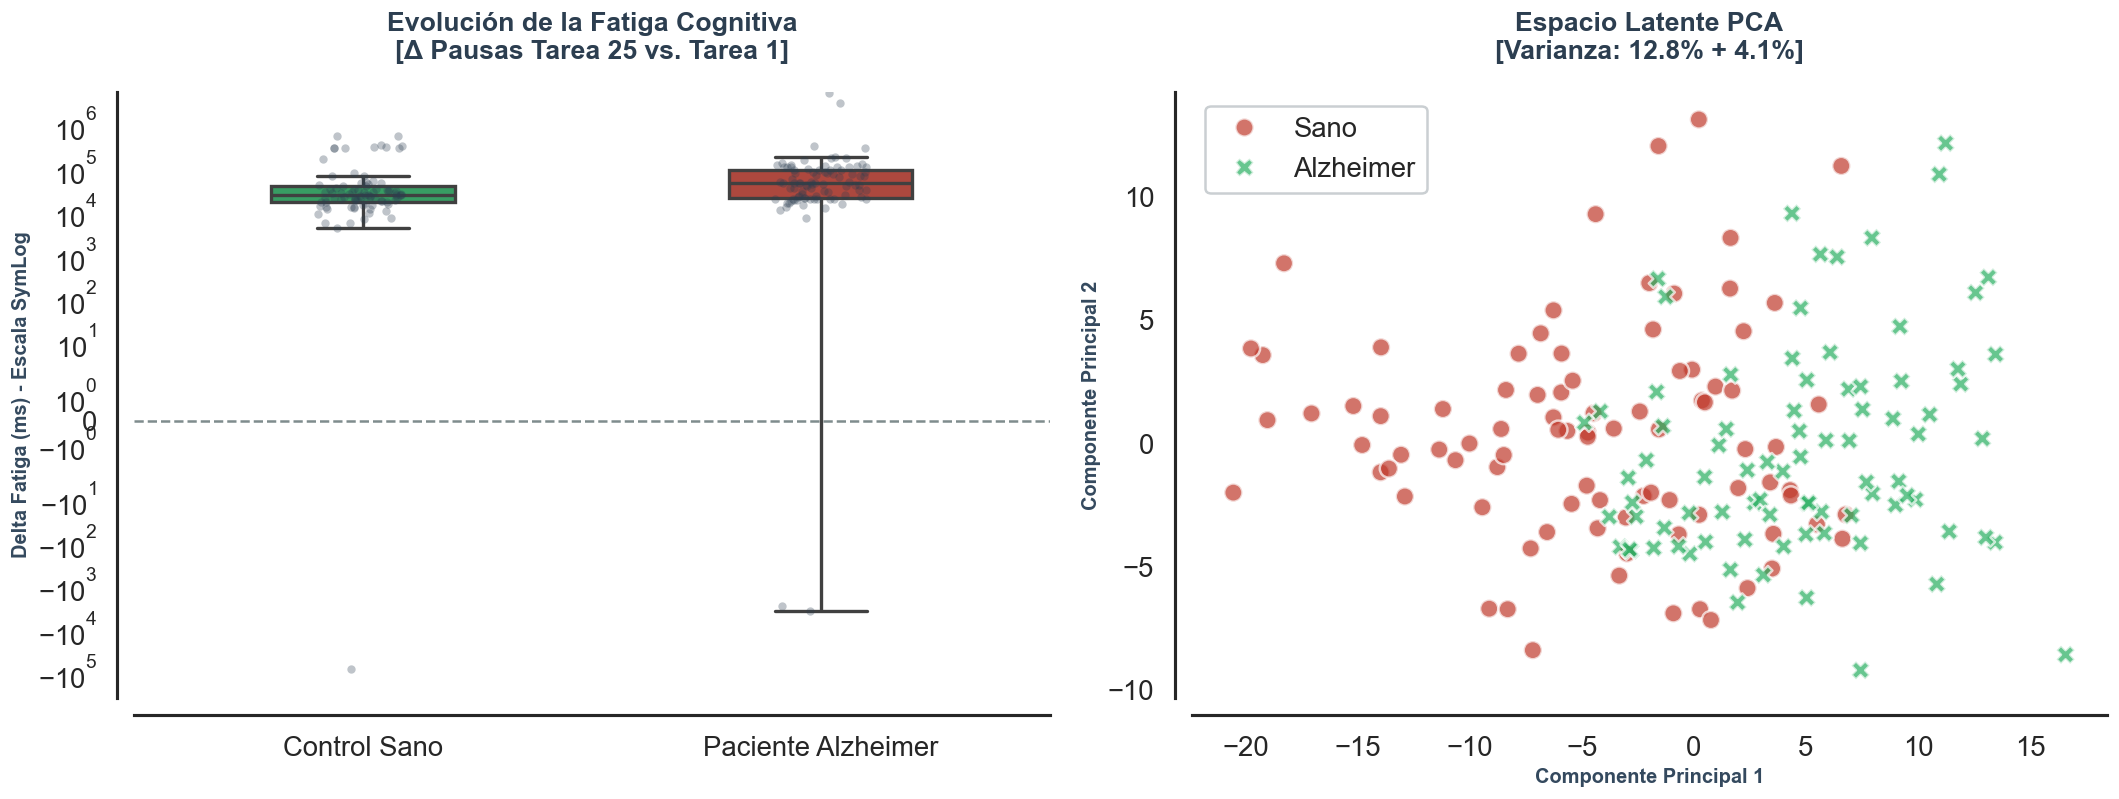

1) fatiga: P-Valor (Mann-Whitney U) = 3.96964e-04
1) El agotamiento cognitivo es significativamente mayor en pacientes.
Se justifica la reducción del protocolo (DARWIN-11).
--------------------------------------------------------------------------------
2) PCA: La separación espacial sugiere que el dataset es altamente clasificable.
El solapamiento indica que las relaciones lineales no son suficientes.


In [11]:
df['delta_fatiga_air'] = df['air_time25'] - df['air_time1']
sanos_delta = df[df['class'] == 'H']['delta_fatiga_air']
pacientes_delta = df[df['class'] == 'P']['delta_fatiga_air']
stat, p_value_fatiga = stats.mannwhitneyu(sanos_delta, pacientes_delta, alternative='two-sided')

# B) PCA
cols_to_drop = ['ID', 'class', 'class_num', 'delta_fatiga_air']
X_pca = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
X_pca_scaled =  StandardScaler().fit_transform(X_pca)

pca = PCA(n_components=2)
componentes = pca.fit_transform(X_pca_scaled)
var_explicada = pca.explained_variance_ratio_ * 100

pca_df = pd.DataFrame(data=componentes, columns=['PC1', 'PC2'])
pca_df['class'] = df['class']
sns.set_theme(style="white", context="talk")
fig, axes = plt.subplots(1, 2, figsize=(18, 7), dpi=120)

labels_dict = {'H': 'Control Sano', 'P': 'Paciente Alzheimer'}

# primero
sns.boxplot(data=df, x='class', y='delta_fatiga_air', palette=color_clases, 
            order=['H', 'P'], width=0.4, fliersize=0, linewidth=2, ax=axes[0], zorder=2)
sns.stripplot(data=df, x='class', y='delta_fatiga_air', color='#2C3E50', 
              alpha=0.3, jitter=True, order=['H', 'P'], ax=axes[0], size=5, zorder=3)

axes[0].set_yscale('symlog')
axes[0].axhline(0, color='#7F8C8D', linestyle='--', linewidth=1.5, zorder=1)

axes[0].set_title('Evolución de la Fatiga Cognitiva\n[Δ Pausas Tarea 25 vs. Tarea 1]', 
                  fontsize=16, fontweight='bold', pad=20, color='#2C3E50')
axes[0].set_xticklabels(['Control Sano', 'Paciente Alzheimer'], fontweight='bold')
axes[0].set_ylabel('Delta Fatiga (ms) - Escala SymLog', fontsize=12, fontweight='bold', color='#34495E')
axes[0].set_xlabel('')

# segundo
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='class', style='class',
                palette=color_clases, s=120, alpha=0.7, edgecolor='white', linewidth=1.5, ax=axes[1])

axes[1].set_title(f'Espacio Latente PCA\n[Varianza: {var_explicada[0]:.1f}% + {var_explicada[1]:.1f}%]', 
                  fontsize=16, fontweight='bold', pad=20, color='#2C3E50')
axes[1].set_xlabel('Componente Principal 1', fontsize=12, fontweight='bold', color='#34495E')
axes[1].set_ylabel('Componente Principal 2', fontsize=12, fontweight='bold', color='#34495E')
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles, ['Sano', 'Alzheimer'], loc='best', frameon=True, facecolor='white', edgecolor='#BDC3C7')

sns.despine(offset=10)
plt.tight_layout()
plt.show()

print(f"1) fatiga: P-Valor (Mann-Whitney U) = {p_value_fatiga:.5e}")
if p_value_fatiga < 0.05:
    print(f"1) El agotamiento cognitivo es significativamente mayor en pacientes.")
    print(f"Se justifica la reducción del protocolo (DARWIN-11).")
print("-" * 80)
print(f"2) PCA: La separación espacial sugiere que el dataset es altamente clasificable.")
print(f"El solapamiento indica que las relaciones lineales no son suficientes.")

### 8. Síntesis multivariante: La huella clínica (Gráfico de radar)

Por último para el EDA, procedemos a sintetizar los hallazgos en una única visualización de alto impacto clínico: **El Perfil de Deterioro Motor-Cognitivo** o "Huella Clínica".

Para ello, seleccionamos 5 macro-dominios fisiológicos que representan los síntomas cardinales de la neurodegeneración en la escritura:
1. **Carga Cognitiva** (Duda / Pausas en el aire).
2. **Inseguridad** (Levantamientos continuos del bolígrafo).
3. **Lentitud Motora** (Bradiquinesia).
4. **Falta de Fuerza** (Pérdida de tono muscular).
5. **Inestabilidad** (Temblor / *Jerk*).

**Transformación de Dominio:** Para que el gráfico sea intuitivo (donde una mayor expansión del polígono signifique un mayor daño patológico), las variables de "Fuerza" y "Velocidad" han sido invertidas matemáticamente. Posteriormente, todas las métricas se han escalado (0 a 1) para permitir su representación en un mismo espacio polar. Este enfoque holístico demuestra visualmente la viabilidad del diagnóstico algorítmico antes de entrar en la fase de modelado predictivo.

In [ ]:
dominios = {
    'Carga Cognitiva\n(Duda)': 'global_air_time',
    'Inestabilidad\n(Temblor)': 'global_mean_jerk_on_paper',
    'Falta de Fuerza\n(Invertido)': 'global_pressure_mean', 
    'Lentitud Motora\n(Invertido)': 'global_mean_speed_on_paper', 
    'Inseguridad\n(Pausas)': 'global_num_of_pendown'
}

df_radar = df_macro[['class'] + list(dominios.values())].copy()
# Invertimos presión y velocidad para que mayor área = mayor deterioro clínico
df_radar['global_pressure_mean'] = df_radar['global_pressure_mean'] * -1
df_radar['global_mean_speed_on_paper'] = df_radar['global_mean_speed_on_paper'] * -1

scaler_radar = MinMaxScaler()
columnas_numericas = list(dominios.values())
df_radar[columnas_numericas] = scaler_radar.fit_transform(df_radar[columnas_numericas])

radar_medias = df_radar.groupby('class').mean()

categorias = list(dominios.keys())
N = len(categorias)
angulos = [n / float(N) * 2 * math.pi for n in range(N)]
angulos += angulos[:1] 
plt.style.use('default')
fig = plt.figure(figsize=(10, 10), dpi=120)
ax = plt.subplot(111, polar=True)

color_sano = '#27AE60'    
color_alzheimer = '#C0392B' 
ax.set_theta_offset(math.pi / 2)
ax.set_theta_direction(-1)
plt.xticks(angulos[:-1], categorias, color='#2C3E50', size=12, fontweight='bold')
ax.tick_params(axis='x', pad=35)
ax.set_rlabel_position(0)
plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], 
           color="#7F8C8D", size=9) 

plt.ylim(0, 1.1)
ax.grid(color='#BDC3C7', linestyle='--', alpha=0.5, zorder=0)

# Sano (H)
valores_H = radar_medias.loc['H'].values.flatten().tolist()
valores_H += valores_H[:1]
ax.plot(angulos, valores_H, linewidth=3.5, color=color_sano, label='Control Sano (H)', zorder=4)
ax.fill(angulos, valores_H, color=color_sano, alpha=0.15)

# Alzheimer (P)
valores_P = radar_medias.loc['P'].values.flatten().tolist()
valores_P += valores_P[:1]
ax.plot(angulos, valores_P, linewidth=3.5, color=color_alzheimer, label='Paciente Alzheimer (P)', zorder=5)
ax.fill(angulos, valores_P, color=color_alzheimer, alpha=0.3)
plt.title('HUELLA CLÍNICA INTEGRAL\nPerfil de Deterioro Motor-Cognitivo', 
          size=19, fontweight='bold', y=1.15, color='#2C3E50')

legend_elements = [
    Line2D([0], [0], color=color_sano, lw=3, label='Control Sano (H)'),
    Line2D([0], [0], color=color_alzheimer, lw=3, label='Paciente Alzheimer (P)')
]
fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.0, 0.95), 
           frameon=False, fontsize=12)

plt.show()

### Fase 2: Preprocesamiento y Diseño Experimental

Una vez validada la integridad y el potencial predictivo del dataset mediante el EDA, preparamos los datos para su ingesta en los algoritmos de Machine Learning. Esta fase es crítica para garantizar la validez científica y clínica de los modelos resultantes.

Aplicamos tres principios metodológicos innegociables:
1. **Prevención de Fuga de Información (*Data Leakage*):** Las transformaciones matemáticas se ajustarán estricta y exclusivamente sobre el conjunto de entrenamiento (Train). El conjunto de prueba (Test) permanecerá "invisible" para simular pacientes nuevos en una consulta real.
2. **Partición Estratificada (80/20):** Al trabajar con una cohorte clínica pequeña (N=174), una partición aleatoria simple podría desbalancear el conjunto de prueba. La estratificación garantiza que tanto Train como Test mantengan la proporción natural 50/50 de sanos y enfermos.
3. **Normalización Robusta al Outlier Clínico:** Descartamos el `StandardScaler` clásico. En neurodegeneración, un valor extremo (ej. una pausa de 10 segundos por apraxia) no es un error de medición, **es el síntoma**. Utilizaremos `RobustScaler`, que escala los datos basándose en el rango intercuartílico (IQR), protegiendo la distribución sin diluir la gravedad clínica de los valores atípicos.




In [13]:
# Eliminamos cossas surgidas por el EDA
# Nos aseguramos de quedarnos estrictamente con las 450 variables predictoras originales
columnas_eda = ['ID', 'class', 'class_num', 'class', 'delta_fatiga_air']
columnas_globales = [col for col in df.columns if col.startswith('global_')]
columnas_a_borrar = columnas_eda + columnas_globales

X = df.drop(columns=[col for col in columnas_a_borrar if col in df.columns])

# Definimos la variable objetivo (y) usando la columna 'class' original para mantener la trazabilidad clínica
# Mapeamos a binario estándar: P (Alzheimer) = 1, H (Sano) = 0
# en teoría esto está hecho pero por si acaso, lo dejamos explícito para evitar confusiones futuras
if df['class'].dtype not in [int, float]:
    y = df['class'].map({'P': 1, 'H': 0})
else:
    y = df['class']

# División Estratificada (Train / Test)
# Reservamos un 20% de pacientes (aprox. 35 sujetos) como validación final ciega
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Cohorte de Entrenamiento (Train): {X_train.shape[0]} pacientes.")
print(f"Cohorte de Validación Ciega (Test): {X_test.shape[0]} pacientes.")
print(f" Variables predictoras crudas: {X_train.shape[1]}")

Cohorte de Entrenamiento (Train): 139 pacientes.
Cohorte de Validación Ciega (Test): 35 pacientes.
 Variables predictoras crudas: 450


In [14]:
# Normalizamos con RobustScaler para protegernos de la varianza patológica extrema
scaler = RobustScaler()

# Entrenamos el escalador solo con X_train para evitar el Data Leakage
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)

# Proyectamos la transformación sobre los pacientes nuevos (Test)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# Para la persistencia de datos apra siguientes fases
datos_fase2 = {
    'X_train': X_train_scaled,
    'X_test': X_test_scaled,
    'y_train': y_train,
    'y_test': y_test
}

joblib.dump(datos_fase2, '../models/datos_preprocesados_fase2.pkl')


print("Dataset limpio, normalizado y sin fugas de información ha sido guardado.")
print("Archivo generado: '../models/datos_preprocesados_fase2.pkl'")

Dataset limpio, normalizado y sin fugas de información ha sido guardado.
Archivo generado: '../models/datos_preprocesados_fase2.pkl'


El preprocesamiento se apoya en tres decisiones metodológicas que vale la pena justificar:

**1. ¿Por qué normalizar?**
Las variables tienen magnitudes muy distintas (latencias en el orden de $10^4$ ms frente a varianzas de presión en $10^{-4}$). Sin normalizar, los modelos asumirían que lo que tiene valores más grandes es automáticamente más importante. El escalado pone todo en el mismo espacio para que cada variable compita por su poder predictivo real.

**2. ¿Por qué RobustScaler y no StandardScaler?**
El StandardScaler usa la media, que es sensible a valores extremos. En un paciente con Alzheimer, una pausa de 10 segundos por bloqueo cognitivo no es un error de medición: es exactamente el síntoma. Si lo tratamos como outlier y lo diluimos, perdemos información clínica valiosa. El RobustScaler usa la mediana y el IQR, que no se dejan afectar por esos valores extremos.

**3. ¿Por qué ajustar el scaler solo sobre Train?**
Porque si calculamos los parámetros de normalización con datos de test, estamos dejando que el futuro "contamine" el modelo. En clínica equivaldría a ajustar el protocolo de diagnóstico sabiendo ya el resultado. El scaler se ajusta únicamente con Train y luego se aplica en Test sin tocar nada.